In [13]:
"/content/drive/MyDrive/drivable_project"

'/content/drive/MyDrive/drivable_project'

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!ls /content/drive/MyDrive/

 20210805_083127.jpg
 2025062043_copy.pdf
 Classroom
'Colab Notebooks'
 ConfirmationPage-250310180668.pdf
 DOC-20250806-WA0002..jpg
 drivable_project
 EAadhaar_0000004833394520250216134243_17062025175430_copy.pdf
 IMG_20230511_132445_460.jpg
 IMG_20230511_132445_488.jpg
 IMG_20230511_132445_746.jpg
 IMG_20230511_132445_749.jpg
 IMG_20230511_132445_884.jpg
 IMG_20230511_132445_887.jpg
 IMG_20230511_132445_988.jpg
 IMG_20230511_132446_050.jpg
 IMG_20230511_132446_096.jpg
 IMG_20230511_132536_152.jpg
 IMG_20230511_132536_180.jpg
 IMG_20230511_132536_225.jpg
 IMG_20230511_132536_330.jpg
 IMG_20230511_132536_739.jpg
 IMG_20230511_132536_755.jpg
 IMG_20230511_132536_951.jpg
 IMG_20230511_132536_972.jpg
 IMG_20230511_132537_039.jpg
 IMG_20230511_132537_080.jpg
 IMG_20230511_132546_314.jpg
 IMG_20230511_132546_352.jpg
 IMG_20230511_132546_416.jpg
 IMG_20230511_132546_417.jpg
 IMG_20230511_132546_531.jpg
 IMG_20230511_132546_533.jpg
 IMG_20230511_132546_613.jpg
 IMG_20230511_132546_616.jpg
 IMG

In [4]:
!ls /content/drive/MyDrive/drivable_project

data	 deeplab_fast.pth	    deeplab_model.pth  predictions
Dataset  deeplab_final_10epoch.pth  drivable_seg


In [5]:
!ls /content/drive/MyDrive/drivable_project/data

images	masks  model.pth


In [6]:
import os
print(os.path.exists("/content/drive/MyDrive/drivable_project/data/images"))

True


In [7]:
print(device)

cuda


Device: cuda
Total: 200
Valid: 110
Epoch 1/10 Loss: 0.5959
Epoch 2/10 Loss: 0.4708
Epoch 3/10 Loss: 0.3726
Epoch 4/10 Loss: 0.3293
Epoch 5/10 Loss: 0.2660
Epoch 6/10 Loss: 0.2516
Epoch 7/10 Loss: 0.2333
Epoch 8/10 Loss: 0.2228
Epoch 9/10 Loss: 0.2183
Epoch 10/10 Loss: 0.2064
Saved: /content/drive/MyDrive/drivable_project/deeplab_final_10epoch.pth
🔥 FPS: 124.51


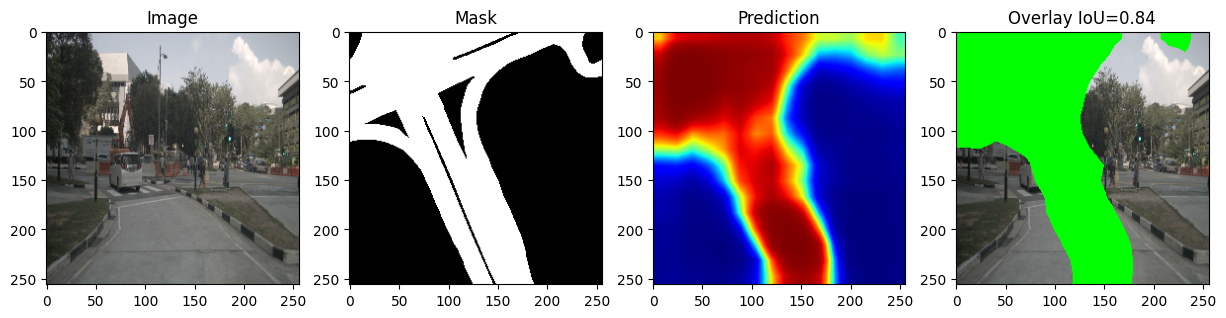

In [12]:
# ==============================
# 1. SETUP
# ==============================
import os, cv2, torch, numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ==============================
# 2. PATHS
# ==============================
image_dir = "/content/drive/MyDrive/drivable_project/data/images"
mask_dir  = "/content/drive/MyDrive/drivable_project/data/masks"

# ==============================
# 3. CLEAN DATASET
# ==============================
class CleanDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        all_images = sorted(os.listdir(image_dir))
        self.valid_images = []

        for img_name in all_images:
            mask_path = os.path.join(mask_dir, img_name)
            mask = cv2.imread(mask_path, 0)

            if mask is not None and mask.sum() > 1000:
                self.valid_images.append(img_name)

        print("Total:", len(all_images))
        print("Valid:", len(self.valid_images))

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_name = self.valid_images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256,256)) / 255.0

        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (256,256)) / 255.0
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).float()

        return image, mask

dataset = CleanDataset(image_dir, mask_dir)

train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# ==============================
# 4. MODEL (Better + Stable)
# ==============================
model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=True)
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
model = model.to(device)

# ==============================
# 5. LOSS (IMPROVED)
# ==============================
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6
    intersection = (pred * target).sum()
    return 1 - (2.*intersection + smooth)/(pred.sum()+target.sum()+smooth)

def loss_fn(pred, target):
    return 0.7*bce(pred, target) + 0.3*dice_loss(pred, target)

# ==============================
# 6. OPTIMIZER + SCHEDULER
# ==============================
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# ==============================
# 7. TRAINING (10 EPOCHS)
# ==============================
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)['out']
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {total_loss/len(train_loader):.4f}")

# ==============================
# 8. SAVE MODEL
# ==============================
save_path = "/content/drive/MyDrive/drivable_project/deeplab_final_10epoch.pth"
torch.save(model.state_dict(), save_path)
print("Saved:", save_path)

# ==============================
# 9. FPS CHECK
# ==============================
measure_fps(model, dataset)

# ==============================
# 10. IoU METRIC
# ==============================
def compute_iou(pred, mask):
    pred = (pred > 0.5).float()
    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

# ==============================
# 11. FPS MEASUREMENT
# ==============================
import time

def measure_fps(model, dataset):
    model.eval()

    img, _ = dataset[0]
    input_img = img.unsqueeze(0).to(device)

    # 🔥 Warmup (important for GPU)
    for _ in range(5):
        _ = model(input_img)

    start = time.time()

    for _ in range(30):   # run multiple times for accuracy
        with torch.no_grad():
            _ = model(input_img)

    end = time.time()

    fps = 30 / (end - start)
    print(f"🔥 FPS: {fps:.2f}")
# ==============================
# 12. VISUALIZATION
# ==============================
def show_prediction(model, dataset, idx=5):
    model.eval()

    img, mask = dataset[idx]
    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(input_img)['out'])[0][0].cpu().numpy()

    pred_bin = (pred > 0.6)

    img_np = img.permute(1,2,0).numpy()

    overlay = img_np.copy()
    overlay[pred_bin] = [0,1,0]

    iou = compute_iou(torch.tensor(pred), mask).item()

    plt.figure(figsize=(15,5))

    plt.subplot(1,4,1)
    plt.title("Image")
    plt.imshow(img_np)

    plt.subplot(1,4,2)
    plt.title("Mask")
    plt.imshow(mask.squeeze(), cmap='gray')

    plt.subplot(1,4,3)
    plt.title("Prediction")
    plt.imshow(pred, cmap='jet')

    plt.subplot(1,4,4)
    plt.title(f"Overlay IoU={iou:.2f}")
    plt.imshow(overlay)

    plt.show()

show_prediction(model, dataset, idx=3)